# Geográfico

## Librerías

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap
import requests
import io
import geopandas as gpd
import os
import pyproj
from shapely.geometry import Point

## Entorno

In [2]:
os.environ['PROJ_DATA'] = os.path.join(os.path.dirname(pyproj.__file__), 'proj_dir', 'share', 'proj')

## Datos

In [3]:
df_si = pd.read_csv('sell_in_suiza_geo.csv')
df_so = pd.read_csv('limpio/sell_out_suiza_v2.csv')
df_cm = pd.read_csv('limpio/customer_master_suiza.csv')
df_tp = pd.read_csv('limpio/TIREPOTENTIAL_suiza.csv')

C:\Users\manue\AppData\Local\Temp\ipykernel_15760\1066003469.py:2: DtypeWarning: Columns (0: FSDCUSTOMERNAME, 1: FSDCUSTOMERFRIENDLYNAME, 2: ROLE) have mixed types. Specify dtype option on import or set low_memory=False.
  df_so = pd.read_csv('limpio/sell_out_suiza_v2.csv')


## Formato

In [4]:
df_si['MONTH_DT'] = pd.to_datetime(df_si['MONTH_DT'])
df_so['MONTHDATE'] = pd.to_datetime(df_so['MONTHDATE'])

df_si['CUSTOMERLATITUDE'] = df_si['CUSTOMERLATITUDE'].str.replace(',', '.').astype(float)
df_si['CUSTOMERLONGITUDE'] = df_si['CUSTOMERLONGITUDE'].str.replace(',', '.').astype(float)
df_si['CUSTOMERPOSTALCODE'] = df_si['CUSTOMERPOSTALCODE'].dropna().astype(int)
df_so['POSTALCODE'] = df_so['POSTALCODE'].dropna().astype(int)
df_cm['CUSTOMERLATITUDE'] = df_cm['CUSTOMERLATITUDE'].astype(str).str.replace(',', '.').astype(float)
df_cm['CUSTOMERLONGITUDE'] = df_cm['CUSTOMERLONGITUDE'].astype(str).str.replace(',', '.').astype(float)

print('Sell In:', df_si.shape)
print('Sell Out:', df_so.shape)
print(df_cm['CUSTOMERLATITUDE'].dtype)
print(df_cm['CUSTOMERLONGITUDE'].dtype)
print('Listo')

Sell In: (294132, 51)
Sell Out: (704699, 33)
float64
float64
Listo


## Distribución de códigos postales

##### Distribución de códigos postales únicos en Sell-in y Sell-Out

In [5]:
print('=== SELL IN ===')
print('CPs únicos:', df_si['CUSTOMERPOSTALCODE'].nunique())
print('\nTop 10 CPs por volumen:')
print(df_si.groupby('CUSTOMERPOSTALCODE')['BILLED_QTY'].sum()
      .sort_values(ascending=False).head(10))

print('\n=== SELL OUT ===')
print('CPs únicos:', df_so['POSTALCODE'].nunique())
print('\nTop 10 CPs por volumen:')
print(df_so.groupby('POSTALCODE')['TOTALSELLOUTQTTY'].sum()
      .sort_values(ascending=False).head(10))

=== SELL IN ===
CPs únicos: 782

Top 10 CPs por volumen:
CUSTOMERPOSTALCODE
1030.0    118456.0
2302.0     94152.0
8107.0     81819.0
8280.0     62453.0
8902.0     37003.0
6210.0     33169.0
4624.0     33103.0
8304.0     32041.0
8036.0     31225.0
1020.0     29884.0
Name: BILLED_QTY, dtype: float64

=== SELL OUT ===
CPs únicos: 2471

Top 10 CPs por volumen:
POSTALCODE
4624.0    255976.0
6300.0     41253.0
8952.0     41009.0
5745.0     35917.0
1023.0     31451.0
8050.0     25794.0
6600.0     21690.0
8048.0     21069.0
7000.0     16091.0
1227.0     15031.0
Name: TOTALSELLOUTQTTY, dtype: float64


##### Concentración de volumen de los códigos postales

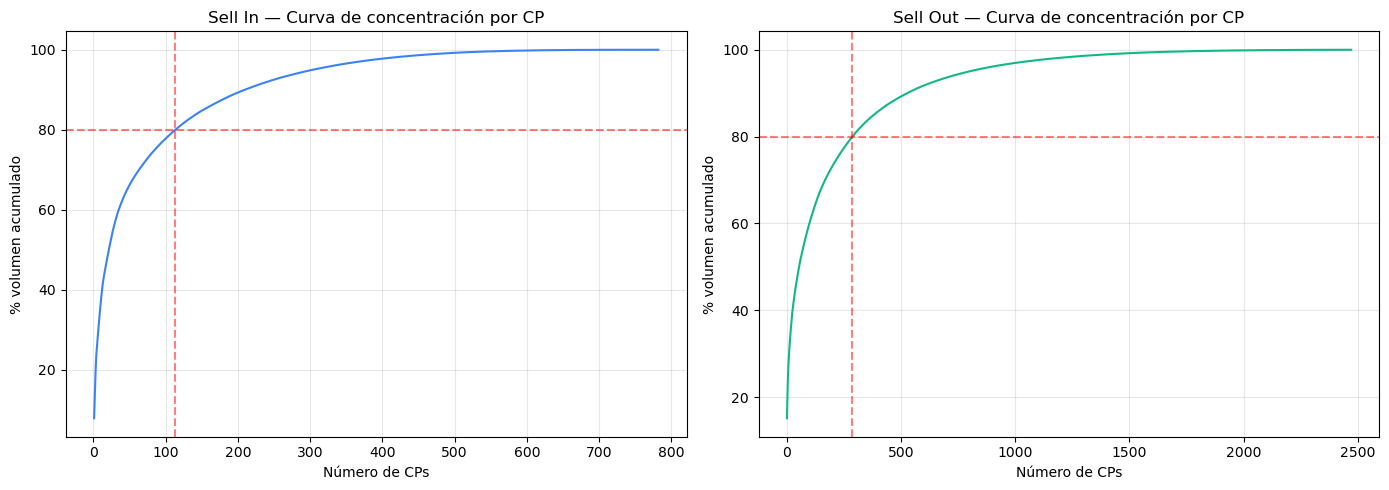

Sell In — CPs que acumulan el 80% del volumen: 113
Sell Out — CPs que acumulan el 80% del volumen: 287


In [6]:
si_cp = df_si.groupby('CUSTOMERPOSTALCODE')['BILLED_QTY'].sum().sort_values(ascending=False)
so_cp = df_so.groupby('POSTALCODE')['TOTALSELLOUTQTTY'].sum().sort_values(ascending=False)

si_cp_pct = (si_cp.cumsum() / si_cp.sum() * 100)
so_cp_pct = (so_cp.cumsum() / so_cp.sum() * 100)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, len(si_cp_pct)+1), si_cp_pct, color='#3B82F6', linewidth=1.5)
axes[0].axhline(y=80, color='red', linestyle='--', alpha=0.5)
axes[0].axvline(x=(si_cp_pct <= 80).sum(), color='red', linestyle='--', alpha=0.5)
axes[0].set_title('Sell In — Curva de concentración por CP')
axes[0].set_xlabel('Número de CPs')
axes[0].set_ylabel('% volumen acumulado')
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, len(so_cp_pct)+1), so_cp_pct, color='#10B981', linewidth=1.5)
axes[1].axhline(y=80, color='red', linestyle='--', alpha=0.5)
axes[1].axvline(x=(so_cp_pct <= 80).sum(), color='red', linestyle='--', alpha=0.5)
axes[1].set_title('Sell Out — Curva de concentración por CP')
axes[1].set_xlabel('Número de CPs')
axes[1].set_ylabel('% volumen acumulado')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('geo_concentracion_cp.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Sell In — CPs que acumulan el 80% del volumen: {(si_cp_pct <= 80).sum()}')
print(f'Sell Out — CPs que acumulan el 80% del volumen: {(so_cp_pct <= 80).sum()}')

### Mapa de calor de la distribución de volumen por Código Postal

In [7]:
cp_coords = df_cm.groupby('CUSTOMERPOSTALCODE').agg(
    lat=('CUSTOMERLATITUDE', 'mean'),
    lon=('CUSTOMERLONGITUDE', 'mean')
).reset_index()

print('CPs con coordenadas:', len(cp_coords))
print(cp_coords.head())

CPs con coordenadas: 1176
   CUSTOMERPOSTALCODE        lat       lon
0                1003  46.519190  6.639470
1                1004  46.525544  6.620654
2                1005  46.521250  6.639720
3                1006  46.510490  6.625230
4                1007  46.520223  6.613627


##### Mapa de calor del volumen del Sell-Out por Código Postal

In [8]:
# Volumen Sell Out por CP
so_cp_vol = df_so.groupby('POSTALCODE')['TOTALSELLOUTQTTY'].sum().reset_index()
so_cp_vol.columns = ['CUSTOMERPOSTALCODE', 'volumen']

# Unir con coordenadas
so_map = so_cp_vol.merge(cp_coords, on='CUSTOMERPOSTALCODE', how='inner')
so_map = so_map[so_map['volumen'] > 0].dropna(subset=['lat', 'lon'])

print(f'CPs con coordenadas y volumen: {len(so_map)}')

mapa = folium.Map(location=[46.8, 8.2], zoom_start=8, 
                  tiles='CartoDB positron')

heat_data = [[row['lat'], row['lon'], row['volumen']] 
             for _, row in so_map.iterrows()]
HeatMap(heat_data, radius=15, blur=20, min_opacity=0.4).add_to(mapa)

mapa.save('mapa_sellout_heatmap.html')
print('Mapa guardado como mapa_sellout_heatmap.html')

CPs con coordenadas y volumen: 1108
Mapa guardado como mapa_sellout_heatmap.html


##### Mapa de calor del volumen del Sell-Out por Código Postal (Sin Outlier)

In [9]:
so_map_sin_outlier = so_map[so_map['CUSTOMERPOSTALCODE'] != 4624]

mapa2 = folium.Map(location=[46.8, 8.2], zoom_start=8,
                   tiles='CartoDB positron')

heat_data2 = [[row['lat'], row['lon'], row['volumen']] 
              for _, row in so_map_sin_outlier.iterrows()]
HeatMap(heat_data2, radius=15, blur=20, min_opacity=0.4).add_to(mapa2)

mapa2.save('mapa_sellout_sin_outlier.html')

print('Volumen CP 4624:', so_map[so_map['CUSTOMERPOSTALCODE']==4624]['volumen'].values)
print('% sobre total:', round(so_map[so_map['CUSTOMERPOSTALCODE']==4624]['volumen'].values[0] / so_map['volumen'].sum() * 100, 1), '%')
print('Mapa guardado')

Volumen CP 4624: [255976.]
% sobre total: 17.2 %
Mapa guardado


## Distribución de Cantones

In [10]:
url = "https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_CHE_1.json"
response = requests.get(url)
cantons = gpd.read_file(io.BytesIO(response.content))

print(cantons.columns.tolist())
print(cantons[['NAME_1', 'GID_1']].head(10))

['GID_1', 'GID_0', 'COUNTRY', 'NAME_1', 'VARNAME_1', 'NL_NAME_1', 'TYPE_1', 'ENGTYPE_1', 'CC_1', 'HASC_1', 'ISO_1', 'geometry']
                  NAME_1     GID_1
0                 Aargau   CHE.1_1
1  AppenzellAusserrhoden   CHE.2_1
2   AppenzellInnerrhoden   CHE.3_1
3       Basel-Landschaft   CHE.4_1
4            Basel-Stadt   CHE.5_1
5                   Bern   CHE.6_1
6               Fribourg   CHE.7_1
7                 Genève   CHE.8_1
8                 Glarus   CHE.9_1
9             Graubünden  CHE.10_1


c:\Users\manue\Anaconda\envs\tfg\Lib\site-packages\pyogrio\core.py:36: RuntimeWarning: Could not detect PROJ data files.  Set PROJ_LIB environment variable to the correct path.
  _init_proj_data()


In [11]:
# Crear GeoDataFrame con los CPs y sus coordenadas
cp_coords_geo = cp_coords.dropna(subset=['lat', 'lon']).copy()
cp_coords_geo['geometry'] = cp_coords_geo.apply(
    lambda row: Point(row['lon'], row['lat']), axis=1
)
cp_gdf = gpd.GeoDataFrame(cp_coords_geo, geometry='geometry', crs='EPSG:4326')

# Asegurar mismo CRS
cantons = cantons.to_crs('EPSG:4326')

# Spatial join CP -> cantón
cp_canton = gpd.sjoin(cp_gdf, cantons[['NAME_1', 'geometry']], 
                       how='left', predicate='within')

cp_canton = cp_canton[['CUSTOMERPOSTALCODE', 'NAME_1']].rename(
    columns={'NAME_1': 'CANTON'})

print('CPs con cantón asignado:', cp_canton['CANTON'].notnull().sum())
print('CPs sin cantón:', cp_canton['CANTON'].isnull().sum())
print(cp_canton.head(10))

CPs con cantón asignado: 1165
CPs sin cantón: 11
   CUSTOMERPOSTALCODE CANTON
0                1003   Vaud
1                1004   Vaud
2                1005   Vaud
3                1006   Vaud
4                1007   Vaud
5                1008   Vaud
6                1009   Vaud
7                1018   Vaud
8                1020   Vaud
9                1022   Vaud


##### Volumen por Cantón en sell-in y sell-out

In [12]:
df_so = df_so.merge(cp_canton, left_on='POSTALCODE', 
                    right_on='CUSTOMERPOSTALCODE', how='left')

df_si = df_si.merge(cp_canton, left_on='CUSTOMERPOSTALCODE', 
                    right_on='CUSTOMERPOSTALCODE', how='left')

# Volumen por cantón
so_canton = df_so.groupby('CANTON')['TOTALSELLOUTQTTY'].sum().sort_values(ascending=False)
si_canton = df_si.groupby('CANTON')['BILLED_QTY'].sum().sort_values(ascending=False)

print('=== SELL OUT por cantón ===')
print(so_canton)
print('\n=== SELL IN por cantón ===')
print(si_canton)

=== SELL OUT por cantón ===
CANTON
Solothurn                283342.0
Zürich                   239883.0
Vaud                     131800.0
Bern                     128969.0
Ticino                   114949.0
Aargau                    91109.0
Zug                       63961.0
Fribourg                  54587.0
Valais                    49503.0
SanktGallen               46625.0
Graubünden                43495.0
Lucerne                   40284.0
Genève                    32877.0
Neuchâtel                 29565.0
Schwyz                    26589.0
Thurgau                   25008.0
Basel-Landschaft          24086.0
Basel-Stadt               15186.0
Jura                      15146.0
Nidwalden                  7898.0
Glarus                     5219.0
Obwalden                   3982.0
Schaffhausen               3346.0
AppenzellAusserrhoden      3340.0
Uri                        2743.0
AppenzellInnerrhoden        322.0
Name: TOTALSELLOUTQTTY, dtype: float64

=== SELL IN por cantón ===
CANTON
Zürich 

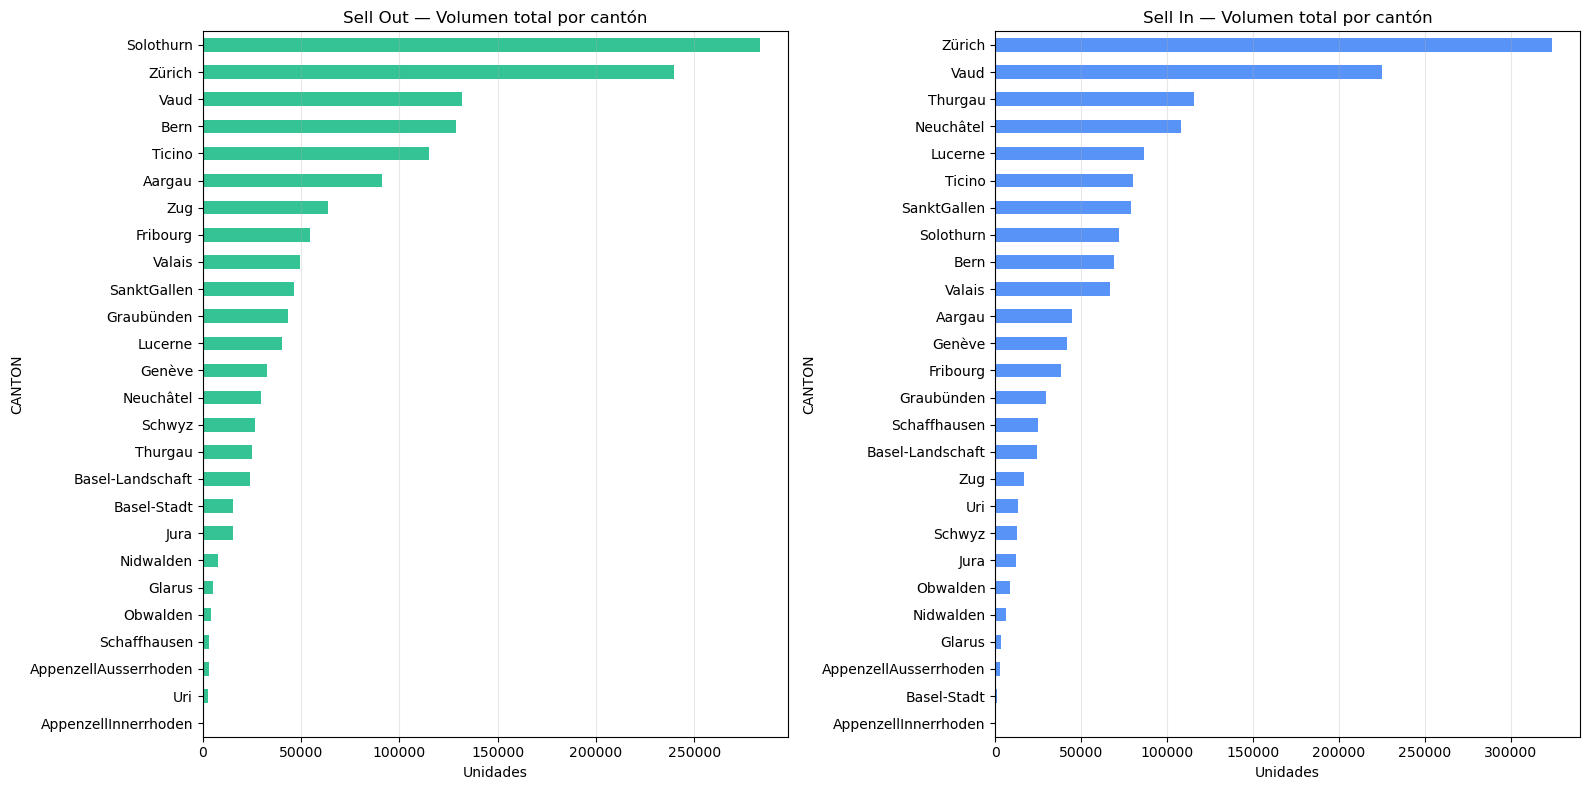

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Sell Out por cantón
so_canton.plot(kind='barh', ax=axes[0], color='#10B981', alpha=0.85)
axes[0].set_title('Sell Out — Volumen total por cantón')
axes[0].set_xlabel('Unidades')
axes[0].invert_yaxis()
axes[0].grid(True, alpha=0.3, axis='x')

# Sell In por cantón
si_canton.plot(kind='barh', ax=axes[1], color='#3B82F6', alpha=0.85)
axes[1].set_title('Sell In — Volumen total por cantón')
axes[1].set_xlabel('Unidades')
axes[1].invert_yaxis()
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('geo_volumen_canton.png', dpi=150, bbox_inches='tight')
plt.show()

## Ratio por Cantón entre el Sell-in y el Sell-Out y Tire Potential

In [14]:
print(df_tp.shape)
print(df_tp.columns.tolist())
print(df_tp.head(3))

(5069750, 16)
['COUNTRYCODE', 'LOCATIONID', 'POSID', 'CHANNELGROUP', 'POSPOSTALCODE', 'MONTHDATE', 'TIRESEASONALITY', 'ABSEGMENT', 'UUHPSEGMENT', 'RIMDIAMETER', 'B2BQUANTITY', 'B2BQUANTITY3MONTHSAGO', 'B2BQUANTITYLASTYEAR', 'B2CQUANTITY', 'B2CQUANTITY3MONTHSAGO', 'B2CQUANTITYLASTYEAR']
  COUNTRYCODE LOCATIONID                                     POSID  \
0          CH     CH8951  pos_ZFzZkZzU1YHWzclUjtWbuJjbNVFZ1QmSJh2Q   
1          CH     CH5408  pos_3F1VGVzVYFjRzIkUjV0awgmTtZDciJkSJh2Q   
2          CH     CH8307  pos_3NVMXFWN6BHbzYjUjtWbu9kR6dVW3FnSJh2Q   

  CHANNELGROUP  POSPOSTALCODE   MONTHDATE TIRESEASONALITY ABSEGMENT  \
0  Car Dealers           8032  2025-02-01          Winter         A   
1  Car Dealers           8153  2024-06-01          Summer         B   
2  Car Dealers           8008  2026-11-01      All Season         B   

  UUHPSEGMENT  RIMDIAMETER  B2BQUANTITY  B2BQUANTITY3MONTHSAGO  \
0           A         18.0     0.001219               0.003994   
1           B  

In [15]:
df_tp['MONTHDATE'] = pd.to_datetime(df_tp['MONTHDATE'])

print('Rango temporal:', df_tp['MONTHDATE'].min(), '→', df_tp['MONTHDATE'].max())
print('\nCanales únicos:', df_tp['CHANNELGROUP'].unique())
print('\nEstacionalidad:', df_tp['TIRESEASONALITY'].unique())

# La demanda total es B2B + B2C
df_tp['TOTAL_POTENTIAL'] = df_tp['B2BQUANTITY'] + df_tp['B2CQUANTITY']

print('\nPotencial total medio por fila:', df_tp['TOTAL_POTENTIAL'].mean())
print('Potencial total suma:', df_tp['TOTAL_POTENTIAL'].sum())

Rango temporal: 2024-01-01 00:00:00 → 2026-12-01 00:00:00

Canales únicos: <StringArray>
['Car Dealers', 'Tyre Retailers', 'Garages', 'Internet BtoC Pure Player']
Length: 4, dtype: str

Estacionalidad: <StringArray>
['Winter', 'Summer', 'All Season']
Length: 3, dtype: str

Potencial total medio por fila: 0.12668935547011778
Potencial total suma: 642283.3598946297


In [16]:
# Añadir cantón al Tire Potential
df_tp = df_tp.merge(cp_canton, left_on='POSPOSTALCODE', 
                    right_on='CUSTOMERPOSTALCODE', how='left')

print('Sin cantón:', df_tp['CANTON'].isnull().sum())

# Agregar potencial por cantón (periodo completo)
tp_canton = df_tp.groupby('CANTON')['TOTAL_POTENTIAL'].sum().sort_values(ascending=False)

print('\nTire Potential por cantón:')
print(tp_canton)

Sin cantón: 719093

Tire Potential por cantón:
CANTON
Zürich                   109126.262295
Vaud                      52808.065648
Bern                      47728.345396
Aargau                    44092.632232
SanktGallen               38313.844644
Genève                    30504.930658
Ticino                    28804.316956
Lucerne                   27103.303821
Valais                    24118.153007
Thurgau                   22203.568062
Basel-Landschaft          21725.634831
Fribourg                  18875.515002
Schwyz                    14116.775416
Solothurn                 13913.470148
Zug                       13135.831116
Neuchâtel                 12360.655050
Graubünden                11249.802928
Basel-Stadt                5962.067851
Schaffhausen               5134.746949
Jura                       3366.783808
AppenzellAusserrhoden      2705.042377
Nidwalden                  2690.314149
AppenzellInnerrhoden       2487.270518
Glarus                     2479.615601
Obwalden  

### Ratio Sell-Out

In [17]:
# Periodo común: 2024-2026 (donde se solapan SO y TP)
df_so_2024 = df_so[df_so['MONTHDATE'] >= '2024-01-01']

so_canton_2024 = df_so_2024.groupby('CANTON')['TOTALSELLOUTQTTY'].sum()

# Ratio Sell Out / Tire Potential
df_ratio = pd.DataFrame({
    'sell_out': so_canton_2024,
    'tire_potential': tp_canton
}).dropna()

df_ratio['cuota_mercado'] = (df_ratio['sell_out'] / df_ratio['tire_potential'] * 100).round(2)
df_ratio = df_ratio.sort_values('cuota_mercado', ascending=False)

print(df_ratio)

                       sell_out  tire_potential  cuota_mercado
CANTON                                                        
Solothurn              129070.0    13913.470148         927.66
Zug                     25585.0    13135.831116         194.77
Graubünden              19757.0    11249.802928         175.62
Nidwalden                4636.0     2690.314149         172.32
Ticino                  49223.0    28804.316956         170.89
Jura                     5415.0     3366.783808         160.84
Fribourg                27824.0    18875.515002         147.41
Basel-Stadt              8020.0     5962.067851         134.52
Bern                    56701.0    47728.345396         118.80
Vaud                    60621.0    52808.065648         114.79
Valais                  24224.0    24118.153007         100.44
Aargau                  43834.0    44092.632232          99.41
Zürich                 106367.0   109126.262295          97.47
Schwyz                  13598.0    14116.775416        

In [18]:
# Ver qué canales incluye el Tire Potential
print('Potencial por canal:')
print(df_tp.groupby('CHANNELGROUP')['TOTAL_POTENTIAL'].sum().sort_values(ascending=False))

print('\nPotencial por año:')
print(df_tp.groupby(df_tp['MONTHDATE'].dt.year)['TOTAL_POTENTIAL'].sum())

# Ver ratio sin Solothurn para tener perspectiva real
df_ratio_limpio = df_ratio[df_ratio.index != 'Solothurn']
print('\nRatio sin Solothurn:')
print(df_ratio_limpio[['cuota_mercado']].sort_values('cuota_mercado', ascending=False))

Potencial por canal:
CHANNELGROUP
Tyre Retailers               209532.070721
Car Dealers                  202767.144831
Garages                      121110.499234
Internet BtoC Pure Player    108873.645108
Name: TOTAL_POTENTIAL, dtype: float64

Potencial por año:
MONTHDATE
2024    203633.625616
2025    219841.717765
2026    218808.016513
Name: TOTAL_POTENTIAL, dtype: float64

Ratio sin Solothurn:
                       cuota_mercado
CANTON                              
Zug                           194.77
Graubünden                    175.62
Nidwalden                     172.32
Ticino                        170.89
Jura                          160.84
Fribourg                      147.41
Basel-Stadt                   134.52
Bern                          118.80
Vaud                          114.79
Valais                        100.44
Aargau                         99.41
Zürich                         97.47
Schwyz                         96.33
Obwalden                       94.17
Glarus  

##### Visualización excluyendo el outlier y ajustando al rango de fechas del Tirepotential

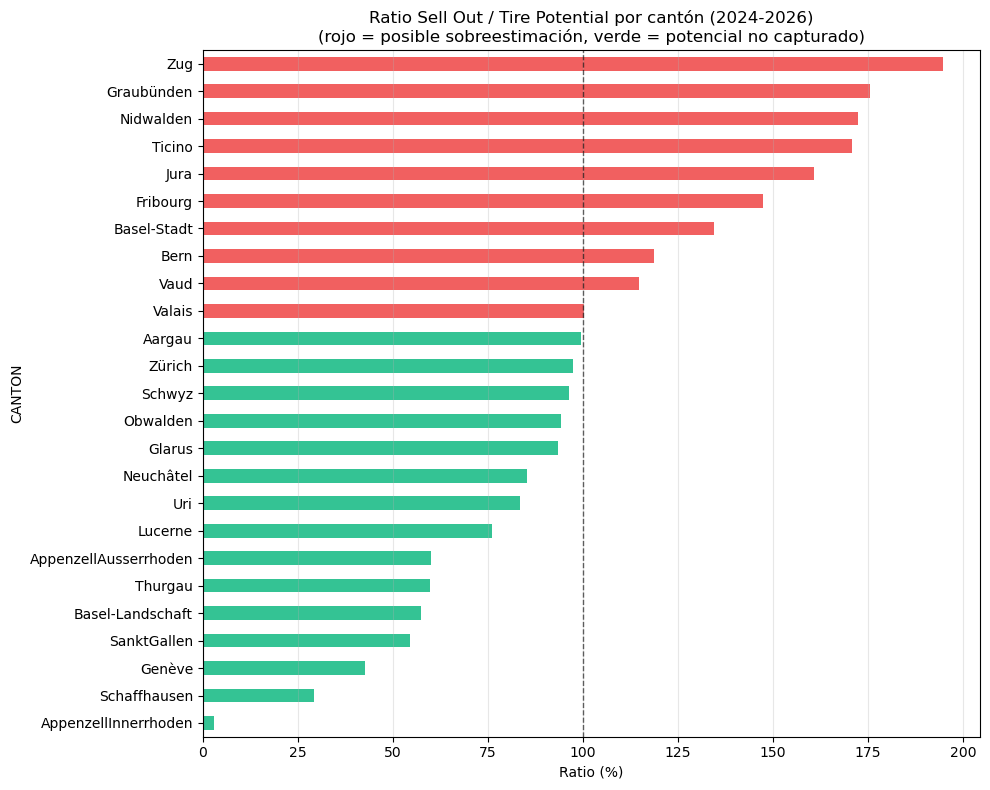

In [19]:
fig, ax = plt.subplots(figsize=(10, 8))

df_plot = df_ratio_limpio['cuota_mercado'].sort_values(ascending=True)

colores = ['#EF4444' if v > 100 else '#10B981' for v in df_plot]

df_plot.plot(kind='barh', ax=ax, color=colores, alpha=0.85)
ax.axvline(x=100, color='black', linewidth=1, linestyle='--', alpha=0.6)
ax.set_title('Ratio Sell Out / Tire Potential por cantón (2024-2026)\n(rojo = posible sobreestimación, verde = potencial no capturado)')
ax.set_xlabel('Ratio (%)')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('geo_ratio_canton.png', dpi=150, bbox_inches='tight')
plt.show()

##### Normalización de valores Sell-Out

In [ ]:
# Filtrar Sell Out al periodo del Tire Potential
df_so_2024 = df_so[
    (df_so['MONTHDATE'] >= '2024-01-01') & 
    (df_so['MONTHDATE'] <= '2026-12-01')
]

so_canton_2024 = df_so_2024.groupby('CANTON')['TOTALSELLOUTQTTY'].sum()

# Recalcular ratio
df_ratio_v2 = pd.DataFrame({
    'sell_out': so_canton_2024,
    'tire_potential': tp_canton
}).dropna()

df_ratio_v2['cuota_mercado'] = (df_ratio_v2['sell_out'] / df_ratio_v2['tire_potential'] * 100).round(2)
df_ratio_v2 = df_ratio_v2.sort_values('cuota_mercado', ascending=False)

print(df_ratio_v2[['cuota_mercado']])

                       cuota_mercado
CANTON                              
Solothurn                     927.66
Zug                           194.77
Graubünden                    175.62
Nidwalden                     172.32
Ticino                        170.89
Jura                          160.84
Fribourg                      147.41
Basel-Stadt                   134.52
Bern                          118.80
Vaud                          114.79
Valais                        100.44
Aargau                         99.41
Zürich                         97.47
Schwyz                         96.33
Obwalden                       94.17
Glarus                         93.40
Neuchâtel                      85.42
Uri                            83.56
Lucerne                        76.04
AppenzellAusserrhoden          59.93
Thurgau                        59.68
Basel-Landschaft               57.30
SanktGallen                    54.64
Genève                         42.70
Schaffhausen                   29.27
A

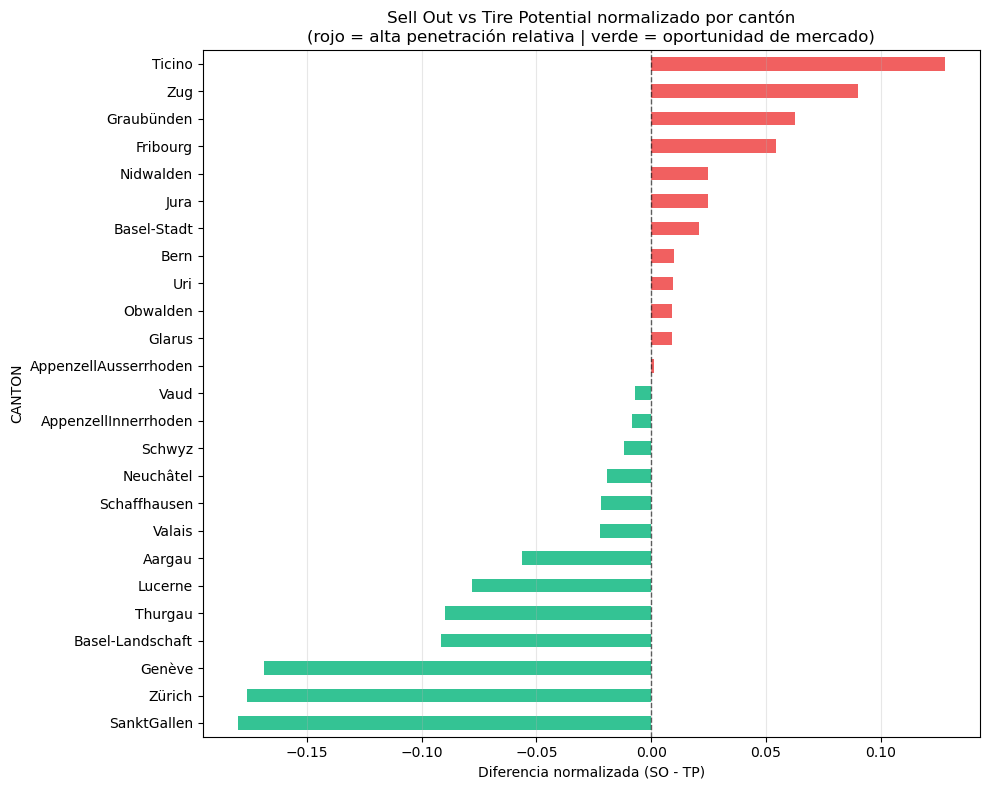

In [21]:
# Normalizar ambas variables al rango 0-1
df_ratio_v2['so_norm'] = (df_ratio_v2['sell_out'] - df_ratio_v2['sell_out'].min()) / \
                          (df_ratio_v2['sell_out'].max() - df_ratio_v2['sell_out'].min())
df_ratio_v2['tp_norm'] = (df_ratio_v2['tire_potential'] - df_ratio_v2['tire_potential'].min()) / \
                          (df_ratio_v2['tire_potential'].max() - df_ratio_v2['tire_potential'].min())

# Diferencia normalizada: positivo = SO > TP (alta penetración), negativo = TP > SO (oportunidad)
df_ratio_v2['diferencia'] = df_ratio_v2['so_norm'] - df_ratio_v2['tp_norm']

# Excluir Solothurn
df_plot = df_ratio_v2[df_ratio_v2.index != 'Solothurn'].sort_values('diferencia', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))

colores = ['#EF4444' if v > 0 else '#10B981' for v in df_plot['diferencia']]
df_plot['diferencia'].plot(kind='barh', ax=ax, color=colores, alpha=0.85)

ax.axvline(x=0, color='black', linewidth=1, linestyle='--', alpha=0.6)
ax.set_title('Sell Out vs Tire Potential normalizado por cantón\n(rojo = alta penetración relativa | verde = oportunidad de mercado)')
ax.set_xlabel('Diferencia normalizada (SO - TP)')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('geo_ratio_normalizado.png', dpi=150, bbox_inches='tight')
plt.show()

##### Mapa Normalizado

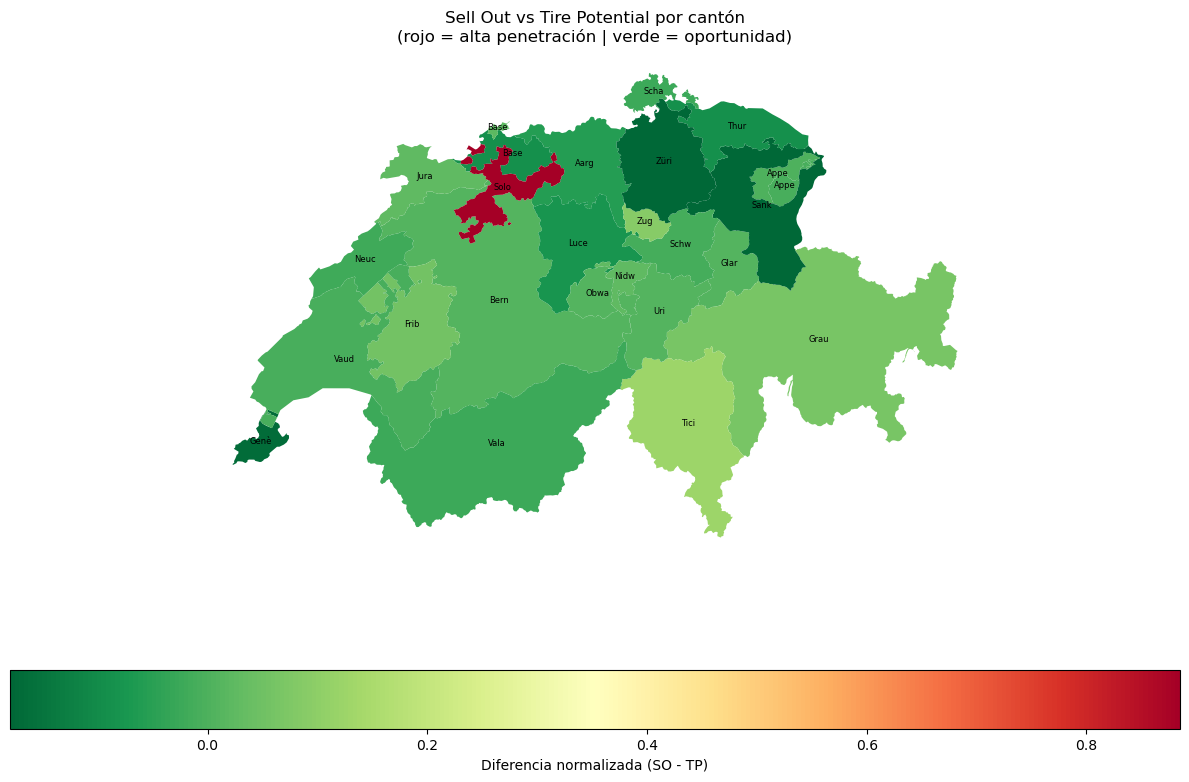

In [ ]:
cantons_plot = cantons.merge(
    df_ratio_v2[['diferencia']].reset_index(),
    left_on='NAME_1', right_on='CANTON', how='left'
)

fig, ax = plt.subplots(figsize=(12, 8))

cantons_plot.plot(
    column='diferencia',
    ax=ax,
    cmap='RdYlGn_r',
    legend=True,
    missing_kwds={'color': 'lightgrey', 'label': 'Sin datos'},
    legend_kwds={'label': 'Diferencia normalizada (SO - TP)',
                 'orientation': 'horizontal'}
)

for _, row in cantons_plot.iterrows():
    if row['geometry'] is not None:
        ax.annotate(row['NAME_1'][:4], 
                   xy=(row['geometry'].centroid.x, row['geometry'].centroid.y),
                   fontsize=6, ha='center', color='black')

ax.set_title('Sell Out vs Tire Potential por cantón\n(rojo = alta penetración | verde = oportunidad)')
ax.set_axis_off()

plt.tight_layout()
plt.savefig('geo_mapa_canton_so.png', dpi=150, bbox_inches='tight')
plt.show()

##### Mapa normalizado sin Outlier

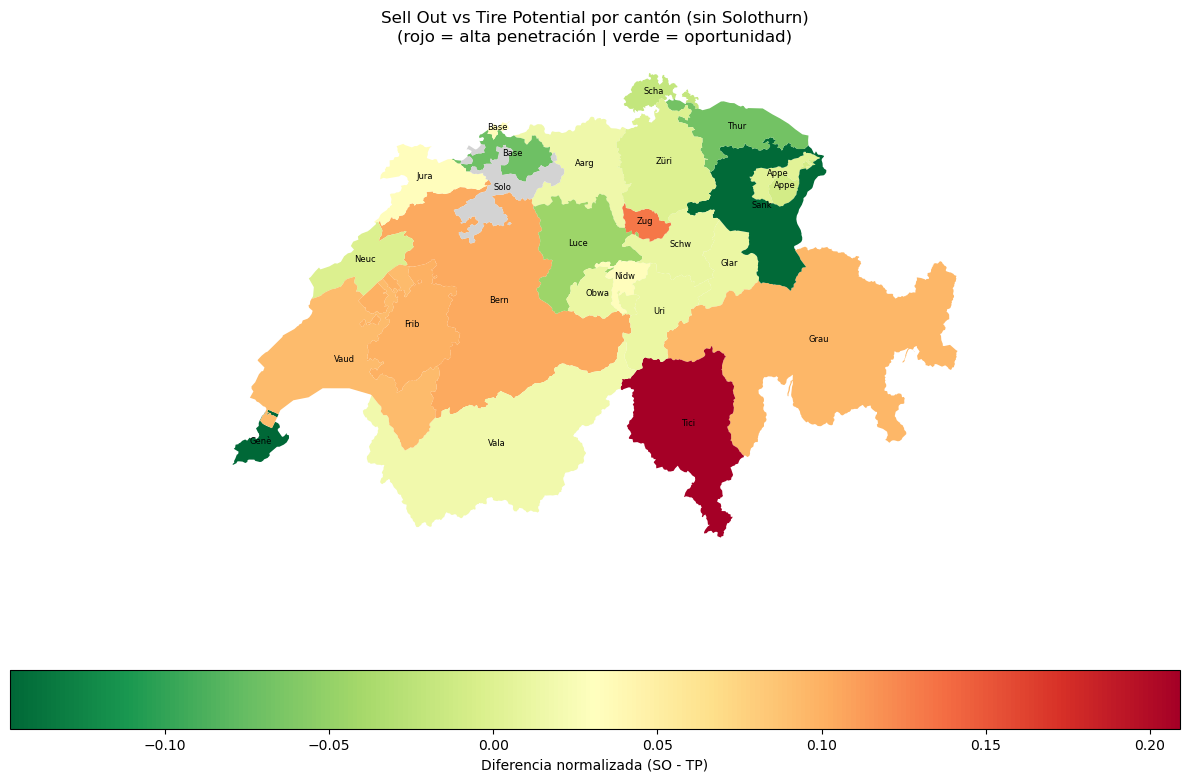

In [23]:
# Excluir Solothurn del mapa
df_ratio_mapa = df_ratio_v2[df_ratio_v2.index != 'Solothurn']

# Renormalizar sin Solothurn
df_ratio_mapa = df_ratio_mapa.copy()
df_ratio_mapa['so_norm'] = (df_ratio_mapa['sell_out'] - df_ratio_mapa['sell_out'].min()) / \
                            (df_ratio_mapa['sell_out'].max() - df_ratio_mapa['sell_out'].min())
df_ratio_mapa['tp_norm'] = (df_ratio_mapa['tire_potential'] - df_ratio_mapa['tire_potential'].min()) / \
                            (df_ratio_mapa['tire_potential'].max() - df_ratio_mapa['tire_potential'].min())
df_ratio_mapa['diferencia'] = df_ratio_mapa['so_norm'] - df_ratio_mapa['tp_norm']

cantons_plot = cantons.merge(
    df_ratio_mapa[['diferencia']].reset_index(),
    left_on='NAME_1', right_on='CANTON', how='left'
)

fig, ax = plt.subplots(figsize=(12, 8))

cantons_plot.plot(
    column='diferencia',
    ax=ax,
    cmap='RdYlGn_r',
    legend=True,
    missing_kwds={'color': 'lightgrey', 'label': 'Sin datos'},
    legend_kwds={'label': 'Diferencia normalizada (SO - TP)',
                 'orientation': 'horizontal'}
)

for _, row in cantons_plot.iterrows():
    if row['geometry'] is not None:
        ax.annotate(row['NAME_1'][:4],
                   xy=(row['geometry'].centroid.x, row['geometry'].centroid.y),
                   fontsize=6, ha='center', color='black')

ax.set_title('Sell Out vs Tire Potential por cantón (sin Solothurn)\n(rojo = alta penetración | verde = oportunidad)')
ax.set_axis_off()

plt.tight_layout()
plt.savefig('geo_mapa_canton_so_limpio.png', dpi=150, bbox_inches='tight')
plt.show()

### Ratio Sell-In

##### Normalización de valores Sell-In con exclusión de Outliers

In [24]:
df_ratio_si = pd.DataFrame({
    'sell_in': si_canton,
    'tire_potential': tp_canton
}).dropna()

print('Top 5 Sell In por cantón:')
print(df_ratio_si['sell_in'].sort_values(ascending=False).head())

Top 5 Sell In por cantón:
CANTON
Zürich       324036.0
Vaud         225240.0
Thurgau      115911.0
Neuchâtel    107835.0
Lucerne       86382.0
Name: sell_in, dtype: float64


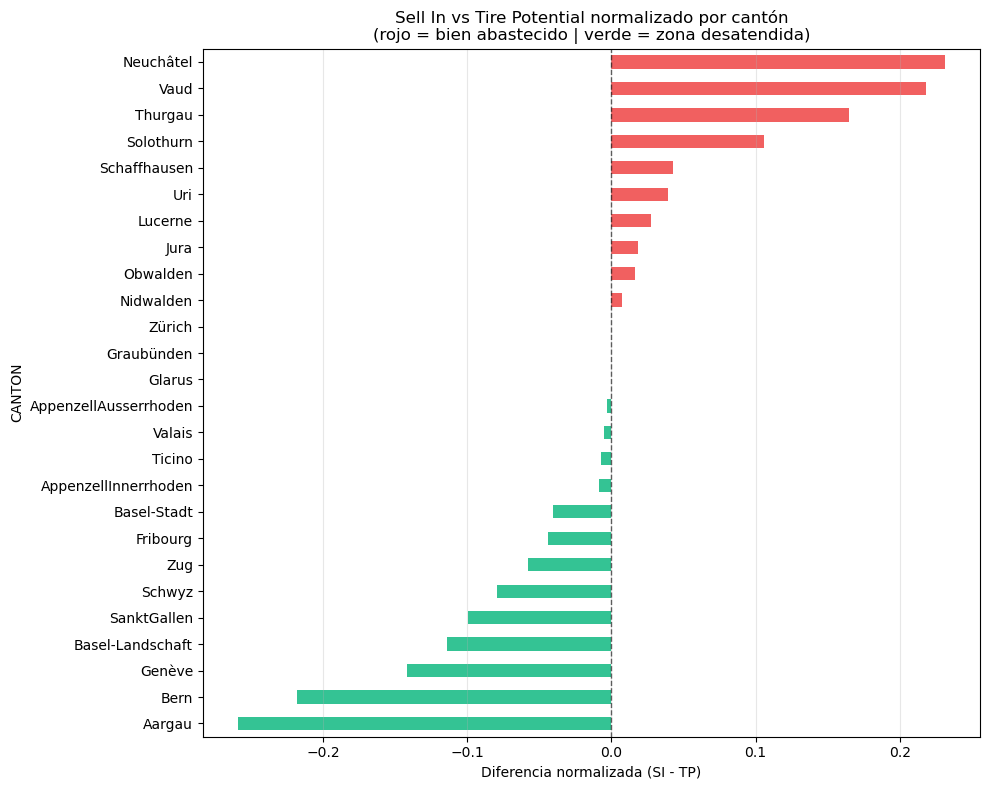

In [26]:
df_ratio_si['si_norm'] = (df_ratio_si['sell_in'] - df_ratio_si['sell_in'].min()) / \
                          (df_ratio_si['sell_in'].max() - df_ratio_si['sell_in'].min())
df_ratio_si['tp_norm'] = (df_ratio_si['tire_potential'] - df_ratio_si['tire_potential'].min()) / \
                          (df_ratio_si['tire_potential'].max() - df_ratio_si['tire_potential'].min())
df_ratio_si['diferencia'] = df_ratio_si['si_norm'] - df_ratio_si['tp_norm']

df_plot_si = df_ratio_si['diferencia'].sort_values(ascending=True)
colores = ['#EF4444' if v > 0 else '#10B981' for v in df_plot_si]

fig, ax = plt.subplots(figsize=(10, 8))
df_plot_si.plot(kind='barh', ax=ax, color=colores, alpha=0.85)
ax.axvline(x=0, color='black', linewidth=1, linestyle='--', alpha=0.6)
ax.set_title('Sell In vs Tire Potential normalizado por cantón\n(rojo = bien abastecido | verde = zona desatendida)')
ax.set_xlabel('Diferencia normalizada (SI - TP)')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('geo_ratio_si_normalizado.png', dpi=150, bbox_inches='tight')
plt.show()

##### Mapa Normalizado

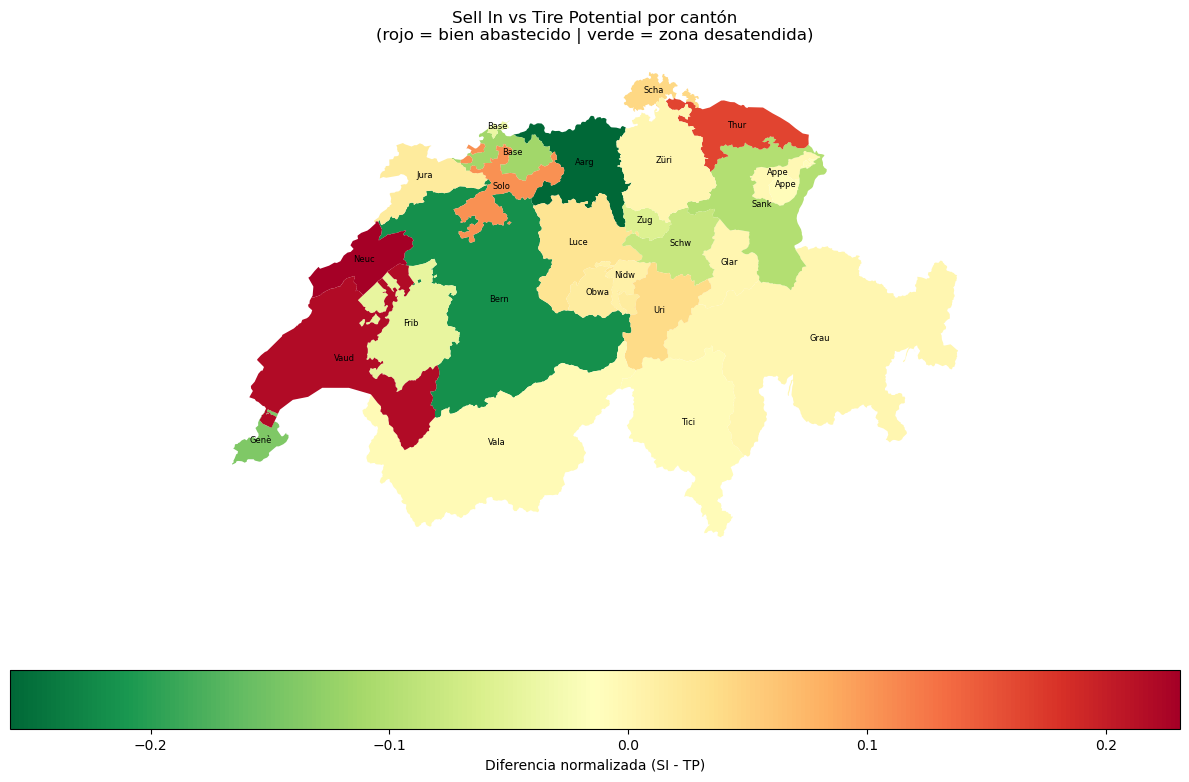

In [27]:
cantons_plot_si = cantons.merge(
    df_ratio_si[['diferencia']].reset_index(),
    left_on='NAME_1', right_on='CANTON', how='left'
)

fig, ax = plt.subplots(figsize=(12, 8))
cantons_plot_si.plot(
    column='diferencia', ax=ax, cmap='RdYlGn_r', legend=True,
    missing_kwds={'color': 'lightgrey', 'label': 'Sin datos'},
    legend_kwds={'label': 'Diferencia normalizada (SI - TP)', 'orientation': 'horizontal'}
)
for _, row in cantons_plot_si.iterrows():
    if row['geometry'] is not None:
        ax.annotate(row['NAME_1'][:4],
                   xy=(row['geometry'].centroid.x, row['geometry'].centroid.y),
                   fontsize=6, ha='center', color='black')
ax.set_title('Sell In vs Tire Potential por cantón\n(rojo = bien abastecido | verde = zona desatendida)')
ax.set_axis_off()
plt.tight_layout()
plt.savefig('geo_mapa_canton_si.png', dpi=150, bbox_inches='tight')
plt.show()

Las zonas de recepción de suministro están en la zona francófona y el Este (para la capital), el sur es más zona de venta final (si nos fijamos en el mapa del Sell-Out), pero el sell out tiene poca muestras así que depende del cp de las empresas presentes, se puede notar que Solo también tiene presencia alta de recepción, por el centro de distribución probablemente

## Tipo de Canal por Cantón

In [28]:
tp_canal_canton = df_tp.groupby(['CANTON', 'CHANNELGROUP'])['TOTAL_POTENTIAL'].sum().unstack()
tp_canal_canton = tp_canal_canton.div(tp_canal_canton.sum(axis=1), axis=0) * 100  # normalizar a %

print(tp_canal_canton.round(1))

CHANNELGROUP           Car Dealers  Garages  Internet BtoC Pure Player  \
CANTON                                                                   
Aargau                        41.2     14.2                       14.1   
AppenzellAusserrhoden         16.8     27.9                       21.4   
AppenzellInnerrhoden          41.5      7.7                       30.9   
Basel-Landschaft              26.5     19.6                       16.7   
Basel-Stadt                   41.4     17.2                       16.7   
Bern                          38.3     17.5                       13.8   
Fribourg                      38.9     14.5                       15.5   
Genève                        25.2     20.1                       17.7   
Glarus                        36.1     20.8                       15.1   
Graubünden                    30.3     16.3                       19.3   
Jura                          43.8     15.3                        9.2   
Lucerne                       29.7    

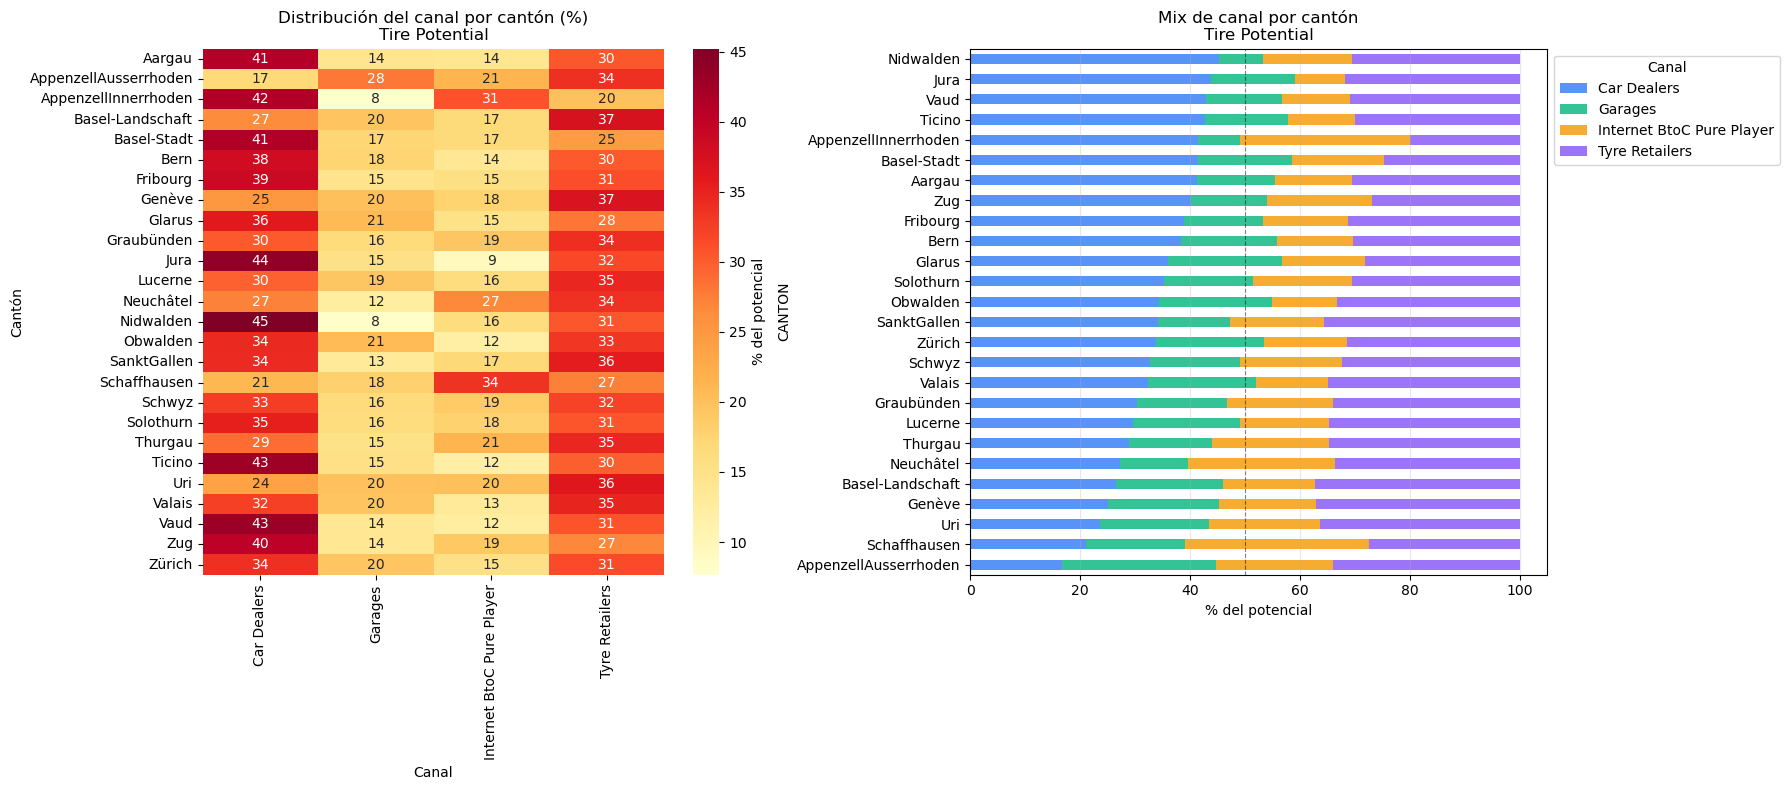

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Heatmap
sns.heatmap(tp_canal_canton, annot=True, fmt='.0f', cmap='YlOrRd',
            ax=axes[0], cbar_kws={'label': '% del potencial'})
axes[0].set_title('Distribución del canal por cantón (%)\nTire Potential')
axes[0].set_xlabel('Canal')
axes[0].set_ylabel('Cantón')

# Barras apiladas ordenadas por Car Dealers
tp_canal_sorted = tp_canal_canton.sort_values('Car Dealers', ascending=True)
tp_canal_sorted.plot(kind='barh', stacked=True, ax=axes[1],
                     color=['#3B82F6', '#10B981', '#F59E0B', '#8B5CF6'],
                     alpha=0.85)
axes[1].set_title('Mix de canal por cantón\nTire Potential')
axes[1].set_xlabel('% del potencial')
axes[1].legend(title='Canal', bbox_to_anchor=(1, 1))
axes[1].axvline(x=50, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('geo_canal_canton.png', dpi=150, bbox_inches='tight')
plt.show()

## Distribución de segmento por Cantón

In [30]:
print('=== ABSEGMENT ===')
print(df_so['ABSEGMENT'].value_counts())

print('\n=== UUHPSEGMENT ===')
print(df_so['UUHPSEGMENT'].value_counts())

=== ABSEGMENT ===
ABSEGMENT
B    478617
A    211127
Name: count, dtype: int64

=== UUHPSEGMENT ===
UUHPSEGMENT
B       478617
UUHP    106741
A       104386
Name: count, dtype: int64


In [31]:
so_seg_canton = df_so.groupby(['CANTON', 'UUHPSEGMENT'])['TOTALSELLOUTQTTY'].sum().unstack()
so_seg_canton = so_seg_canton.div(so_seg_canton.sum(axis=1), axis=0) * 100

print(so_seg_canton.round(1))

UUHPSEGMENT               A     B  UUHP
CANTON                                 
Aargau                 17.4  68.7  13.8
AppenzellAusserrhoden  10.8  77.9  11.3
AppenzellInnerrhoden   12.6  70.8  16.7
Basel-Landschaft       15.8  60.9  23.3
Basel-Stadt            15.9  73.8  10.3
Bern                   14.4  74.2  11.3
Fribourg               16.9  73.1  10.0
Genève                 16.3  66.7  16.9
Glarus                 14.1  71.7  14.2
Graubünden             17.6  66.4  16.1
Jura                   14.6  76.0   9.4
Lucerne                15.1  71.2  13.7
Neuchâtel              12.8  78.0   9.2
Nidwalden              13.4  78.6   8.1
Obwalden               15.2  76.9   8.0
SanktGallen            15.4  72.5  12.1
Schaffhausen           15.5  67.8  16.7
Schwyz                 15.3  73.8  10.9
Solothurn              17.2  73.9   9.0
Thurgau                15.4  73.5  11.0
Ticino                 13.8  73.1  13.1
Uri                    15.4  75.7   8.9
Valais                 17.3  68.7  14.0


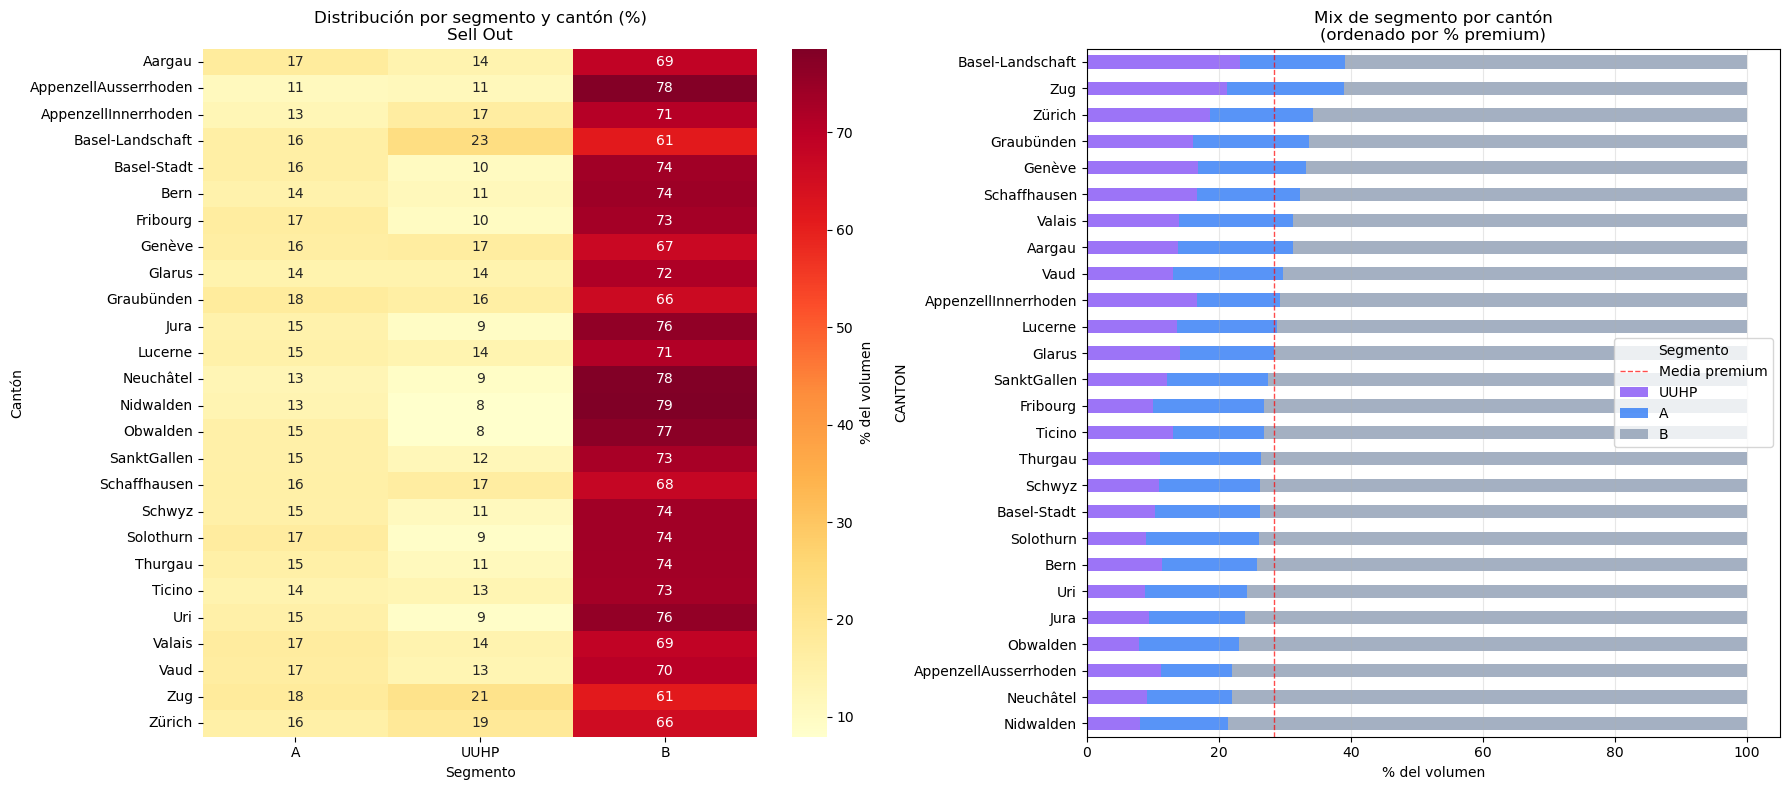

=== Ranking por % premium (A + UUHP) ===
CANTON
Basel-Landschaft         39.1
Zug                      39.0
Zürich                   34.3
Graubünden               33.6
Genève                   33.3
Schaffhausen             32.2
Valais                   31.3
Aargau                   31.3
Vaud                     29.7
AppenzellInnerrhoden     29.2
Lucerne                  28.8
Glarus                   28.3
SanktGallen              27.5
Fribourg                 26.9
Ticino                   26.9
Thurgau                  26.5
Schwyz                   26.2
Basel-Stadt              26.2
Solothurn                26.1
Bern                     25.8
Uri                      24.3
Jura                     24.0
Obwalden                 23.1
AppenzellAusserrhoden    22.1
Neuchâtel                22.0
Nidwalden                21.4
Name: premium, dtype: float64


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Ordenar por segmento premium (A + UUHP)
so_seg_canton['premium'] = so_seg_canton['A'] + so_seg_canton['UUHP']
so_seg_sorted = so_seg_canton.sort_values('premium', ascending=True)

# Heatmap
sns.heatmap(so_seg_canton[['A', 'UUHP', 'B']], annot=True, fmt='.0f', 
            cmap='YlOrRd', ax=axes[0],
            cbar_kws={'label': '% del volumen'})
axes[0].set_title('Distribución por segmento y cantón (%)\nSell Out')
axes[0].set_xlabel('Segmento')
axes[0].set_ylabel('Cantón')

# Barras apiladas ordenadas por premium
so_seg_sorted[['UUHP', 'A', 'B']].plot(
    kind='barh', stacked=True, ax=axes[1],
    color=['#8B5CF6', '#3B82F6', '#94A3B8'],
    alpha=0.85
)
axes[1].axvline(x=so_seg_canton['premium'].mean(), color='red', 
                linewidth=1, linestyle='--', alpha=0.7, label='Media premium')
axes[1].set_title('Mix de segmento por cantón\n(ordenado por % premium)')
axes[1].set_xlabel('% del volumen')
axes[1].legend(title='Segmento')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('geo_segmento_canton.png', dpi=150, bbox_inches='tight')
plt.show()

# Ranking premium
print('=== Ranking por % premium (A + UUHP) ===')
print(so_seg_canton['premium'].sort_values(ascending=False).round(1))